# Task 6: Neural Networks Core Setup

**Goal:** Construct a simple neural network layer to classify dataset rows, then train, test, and graph the loss curve.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — built into scikit-learn (`sklearn.datasets.load_breast_cancer`), binary classification (malignant vs. benign). Using a built-in dataset avoids working-directory / file-path issues.

**Model:** `sklearn.neural_network.MLPClassifier` — a single hidden-layer feedforward neural network (multi-layer perceptron).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Configuration

In [2]:
# ---- Config / constants (no hardcoded paths or magic numbers scattered in code) ----
PROJECT_ROOT = Path.cwd()
VIS_DIR = PROJECT_ROOT / "visualizations"
VIS_DIR.mkdir(exist_ok=True)

TEST_SIZE = 0.2
HIDDEN_LAYER_SIZES = (16,)   # single hidden layer, 16 neurons -> the "core" NN layer
MAX_ITER = 500
LEARNING_RATE_INIT = 0.01
ACTIVATION = "relu"
SOLVER = "adam"

LOSS_CURVE_PATH = VIS_DIR / "loss_curve.png"
CONFUSION_MATRIX_PATH = VIS_DIR / "confusion_matrix.png"


## 2. Load Data

In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
X.head()


Feature matrix shape: (569, 30)
Target distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Post-load validation checks

In [4]:
# ---- Validation checks ----
assert X.isnull().sum().sum() == 0, "Unexpected nulls in feature matrix"
assert y.isnull().sum() == 0, "Unexpected nulls in target"
assert set(y.unique()) == {0, 1}, "Target should be binary (0/1)"
assert X.shape[0] == y.shape[0], "Feature/target row count mismatch"
assert (X.dtypes.apply(lambda d: np.issubdtype(d, np.number))).all(), "All features should be numeric"

print("All validation checks passed.")


All validation checks passed.


## 3. Train/Test Split & Scaling

In [5]:
def split_and_scale(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """Split into train/test sets and standardize features (fit on train only)."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


X_train, X_test, y_train, y_test, scaler = split_and_scale(X, y)

assert X_train.shape[1] == X_test.shape[1] == X.shape[1], "Feature count mismatch after scaling"
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (455, 30), Test shape: (114, 30)


## 4. Build & Train the Neural Network

In [6]:
def build_and_train_mlp(X_train, y_train,
                         hidden_layer_sizes=HIDDEN_LAYER_SIZES,
                         activation=ACTIVATION,
                         solver=SOLVER,
                         learning_rate_init=LEARNING_RATE_INIT,
                         max_iter=MAX_ITER,
                         random_state=RANDOM_STATE):
    """Construct and train a simple feedforward neural network classifier."""
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    return model


model = build_and_train_mlp(X_train, y_train)

assert hasattr(model, "loss_curve_"), "Model did not train / loss curve missing"
print(f"Training complete. Iterations run: {model.n_iter_}")
print(f"Final training loss: {model.loss_curve_[-1]:.4f}")


Training complete. Iterations run: 154
Final training loss: 0.0026


## 5. Test & Evaluate

In [7]:
def evaluate_model(model, X_test, y_test):
    """Predict on the test set and report standard classification metrics."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["malignant", "benign"])
    cm = confusion_matrix(y_test, y_pred)
    return y_pred, acc, report, cm


y_pred, accuracy, report, cm = evaluate_model(model, X_test, y_test)

assert 0.0 <= accuracy <= 1.0, "Accuracy out of valid range"
print(f"Test accuracy: {accuracy:.4f}\n")
print(report)


Test accuracy: 0.9561

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



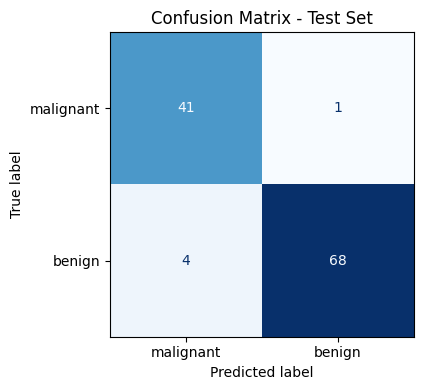

Saved: visualizations/confusion_matrix.png


In [8]:
# Confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=150)
plt.show()

print(f"Saved: {CONFUSION_MATRIX_PATH.relative_to(PROJECT_ROOT)}")


## 6. Loss Curve

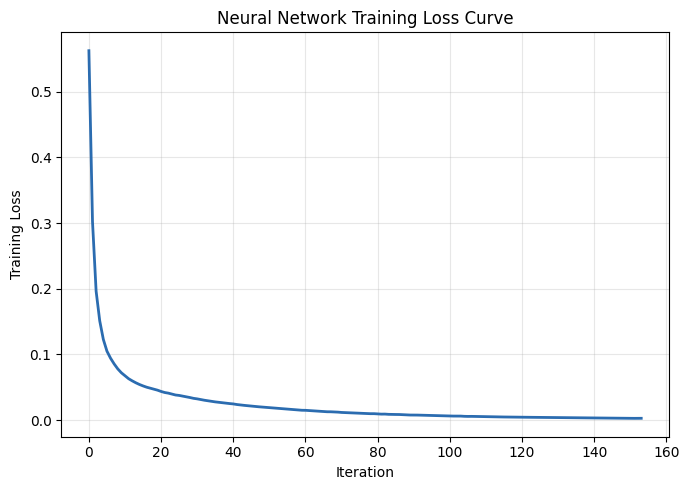

Saved: visualizations/loss_curve.png


In [9]:
def plot_loss_curve(model, save_path):
    """Plot the training loss curve of a fitted MLPClassifier and save it."""
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(model.loss_curve_, color="#2b6cb0", linewidth=2)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Training Loss")
    ax.set_title("Neural Network Training Loss Curve")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


plot_loss_curve(model, LOSS_CURVE_PATH)
print(f"Saved: {LOSS_CURVE_PATH.relative_to(PROJECT_ROOT)}")


## 7. Summary

- Loaded the Breast Cancer Wisconsin dataset (569 rows, 30 numeric features, binary target).
- Split into train/test (80/20, stratified) and standardized features with `StandardScaler`.
- Built a simple neural network (`MLPClassifier`, one hidden layer of 16 neurons, ReLU activation, Adam solver).
- Trained the model and confirmed convergence via `loss_curve_`.
- Evaluated on the held-out test set (accuracy, precision/recall/F1, confusion matrix).
- Plotted and saved the training loss curve to `visualizations/loss_curve.png`.

**Next steps (future tasks):** experiment with additional hidden layers/neurons, regularization (`alpha`), and compare against other classifiers.
